In [6]:
import pandas as pd
data=pd.read_csv("/content/drive/MyDrive/DataA_dev/Machine_failure_fixed.csv")
data

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Power,RotationalSpeed_TorqueRatio,OSF,Temperature_Difference,Average_Temperature,Toolwear_Rate
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,57615.6,44.210526,5054.0,9.0,305.10,0.553360
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,51186.9,60.446735,5820.0,9.5,307.35,0.790514
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,47832.5,68.113208,662.5,9.2,303.90,0.098814
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,67513.2,34.401806,8727.1,9.9,305.95,0.778656
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,58091.4,46.355932,1203.6,11.0,303.50,0.134387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136424,136424,M22284,M,300.1,311.4,1530,37.5,210,0,57375.0,40.800000,7875.0,11.3,305.75,0.830040
136425,136425,H38017,H,297.5,308.5,1447,49.1,2,0,71047.7,29.470468,98.2,11.0,303.00,0.007905
136426,136426,L54690,L,300.5,311.8,1524,38.5,214,0,58674.0,39.584416,8239.0,11.3,306.15,0.845850
136427,136427,L53876,L,301.7,310.9,1447,46.3,42,0,66996.1,31.252700,1944.6,9.2,306.30,0.166008


In [7]:

failure_counts = data['Machine failure'].value_counts()


failure_counts

Machine failure
0    134281
1      2148
Name: count, dtype: int64

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packag

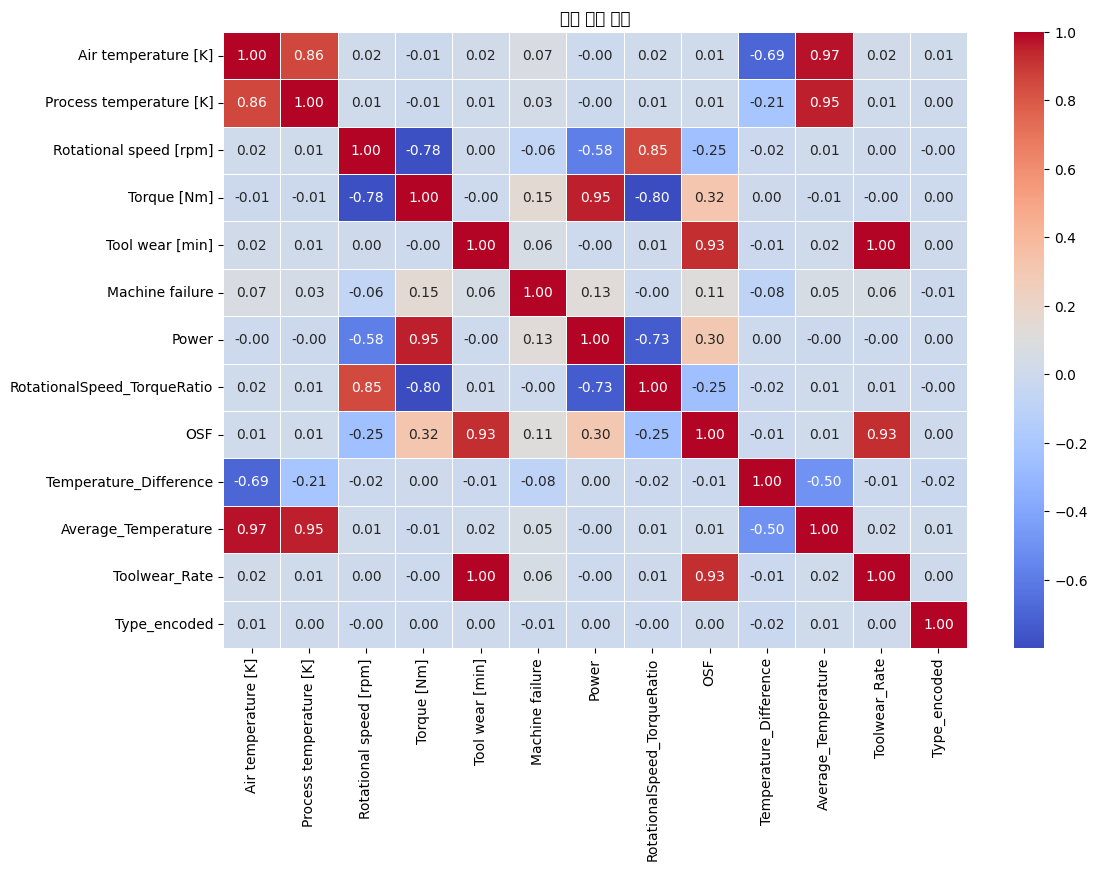

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


# 라벨 인코더 초기화
label_encoder = LabelEncoder()

# 'Type' 열에 라벨 인코딩 적용
data['Type_encoded'] = label_encoder.fit_transform(data['Type'])

# 필요 없는 열 제거
data_cleaned = data.drop(['Product ID', 'id', 'Type'], axis=1)

# 상관 계수 행렬 계산
correlation_matrix = data_cleaned.corr()

# 히트맵으로 상관 계수 행렬 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('상관 계수 행렬')
plt.show()

In [9]:
top_correlations = correlation_matrix['Machine failure'].drop('Machine failure').abs().sort_values(ascending=False).head(5)

print(top_correlations)

Torque [Nm]               0.145793
Power                     0.128222
OSF                       0.111041
Temperature_Difference    0.084536
Air temperature [K]       0.067744
Name: Machine failure, dtype: float64


##모델 첫번째 시행

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# 데이터 로드
data = pd.read_csv('/content/drive/MyDrive/DataA_dev/Machine_failure_fixed.csv')

# 라벨 인코더 초기화 및 'Type' 열에 라벨 인코딩 적용
label_encoder = LabelEncoder()
data['Type_encoded'] = label_encoder.fit_transform(data['Type'])

# 필요 없는 열 제거 및 데이터 준비
data_cleaned = data.drop(['Product ID', 'id', 'Type'], axis=1)

# 데이터에서 Machine failure=0과 1에 대한 샘플링
target_0 = data_cleaned[data_cleaned['Machine failure'] == 0]
target_1 = data_cleaned[data_cleaned['Machine failure'] == 1]
sampled_failure_0 = target_0.sample(n=3200, random_state=42)
sampled_failure_1 = target_1.sample(n=2000, random_state=42)
renew_train = pd.concat([sampled_failure_1, sampled_failure_0])

# 특성 및 타겟 데이터 준비
X = renew_train.drop('Machine failure', axis=1)
y = renew_train['Machine failure']

# 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 파라미터 그리드 설정 및 랜덤 포레스트 모델 교차 검증
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, None],
    'min_samples_split': [4],
    'min_samples_leaf': [2],
    'class_weight': ['balanced']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

# 최적의 모델 선택 및 성능 평가
best_rf = grid_search.best_estimator_
y_valid_proba = best_rf.predict_proba(X_valid)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_valid, y_valid_proba)
threshold_chosen = thresholds[np.argmax(precision + recall)]
y_valid_pred = (y_valid_proba >= threshold_chosen).astype(int)

# 평가 결과 출력
accuracy = accuracy_score(y_valid, y_valid_pred)
conf_mat = confusion_matrix(y_valid, y_valid_pred)
class_report = classification_report(y_valid, y_valid_pred)

print("Validation Accuracy:", accuracy)
print("Validation Confusion Matrix:\n", conf_mat)
print("Validation Classification Report:\n", class_report)
print("Best Model Parameters:", grid_search.best_params_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Validation Accuracy: 0.8711538461538462
Validation Confusion Matrix:
 [[577  63]
 [ 71 329]]
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90       640
           1       0.84      0.82      0.83       400

    accuracy                           0.87      1040
   macro avg       0.86      0.86      0.86      1040
weighted avg       0.87      0.87      0.87      1040

Best Model Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 100}


## Machine failure 실패/비실패 비율 1:1로 조정 후 시행

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# 데이터 로드
data = pd.read_csv('/content/drive/MyDrive/DataA_dev/Machine_failure_fixed.csv')

# 라벨 인코더 초기화 및 'Type' 열에 라벨 인코딩 적용
label_encoder = LabelEncoder()
data['Type_encoded'] = label_encoder.fit_transform(data['Type'])

# 필요 없는 열 제거 및 데이터 준비
data_cleaned = data.drop(['Product ID', 'id', 'Type'], axis=1)

# 데이터에서 Machine failure=0과 1에 대한 샘플링
target_0 = data_cleaned[data_cleaned['Machine failure'] == 0]
target_1 = data_cleaned[data_cleaned['Machine failure'] == 1]
sampled_failure_0 = target_0.sample(n=2000, random_state=42)
sampled_failure_1 = target_1.sample(n=2000, random_state=42)
renew_train = pd.concat([sampled_failure_1, sampled_failure_0])

# 특성 및 타겟 데이터 준비
X = renew_train.drop('Machine failure', axis=1)
y = renew_train['Machine failure']

# 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 파라미터 그리드 설정 및 랜덤 포레스트 모델 교차 검증
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, None],
    'min_samples_split': [4],
    'min_samples_leaf': [2],
    'class_weight': ['balanced']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

# 최적의 모델 선택 및 성능 평가
best_rf = grid_search.best_estimator_
y_valid_proba = best_rf.predict_proba(X_valid)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_valid, y_valid_proba)
threshold_chosen = thresholds[np.argmax(precision + recall)]
y_valid_pred = (y_valid_proba >= threshold_chosen).astype(int)

# 평가 결과 출력
accuracy = accuracy_score(y_valid, y_valid_pred)
conf_mat = confusion_matrix(y_valid, y_valid_pred)
class_report = classification_report(y_valid, y_valid_pred)

print("Validation Accuracy:", accuracy)
print("Validation Confusion Matrix:\n", conf_mat)
print("Validation Classification Report:\n", class_report)
print("Best Model Parameters:", grid_search.best_params_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Validation Accuracy: 0.855
Validation Confusion Matrix:
 [[337  63]
 [ 53 347]]
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85       400
           1       0.85      0.87      0.86       400

    accuracy                           0.85       800
   macro avg       0.86      0.85      0.85       800
weighted avg       0.86      0.85      0.85       800

Best Model Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 100}


##클래스 가중치 설정
## balanced -> {0: 1, 1: 2}, {0: 1, 1: 3}

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 데이터 로드 및 준비
data = pd.read_csv('/content/drive/MyDrive/DataA_dev/Machine_failure_fixed.csv')

data_cleaned = data.drop(['Product ID', 'id', 'Type', 'Toolwear_Rate' ,'Average_Temperature' ], axis=1)

# 불균형 데이터 처리
sampled_failure_0 = data_cleaned[data_cleaned['Machine failure'] == 0].sample(n=2000, random_state=42)
sampled_failure_1 = data_cleaned[data_cleaned['Machine failure'] == 1].sample(n=2000, random_state=42)
renew_train = pd.concat([sampled_failure_1, sampled_failure_0])

X = renew_train.drop('Machine failure', axis=1)
y = renew_train['Machine failure']

# 데이터 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 하이퍼파라미터 설정 및 랜덤 포레스트 모델 교차 검증
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, None],
    'min_samples_split': [4],
    'min_samples_leaf': [2],
    'class_weight': [{0: 1, 1: 2}, {0: 1, 1: 3}]  # 실패 클래스에 더 높은 가중치 설정
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='f1', verbose=1)
grid_search.fit(X_train, y_train)

# 최적의 모델 선택 및 성능 평가
best_rf = grid_search.best_estimator_
y_valid_pred = best_rf.predict(X_valid)

print("Validation Accuracy:", accuracy_score(y_valid, y_valid_pred))
print("Validation Confusion Matrix:\n", confusion_matrix(y_valid, y_valid_pred))
print("Validation Classification Report:\n", classification_report(y_valid, y_valid_pred))
print("Best Model Parameters:", grid_search.best_params_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Validation Accuracy: 0.85375
Validation Confusion Matrix:
 [[338  62]
 [ 55 345]]
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85       400
           1       0.85      0.86      0.86       400

    accuracy                           0.85       800
   macro avg       0.85      0.85      0.85       800
weighted avg       0.85      0.85      0.85       800

Best Model Parameters: {'class_weight': {0: 1, 1: 2}, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 150}


##오버 샘플링

#SMOTE기법


In [12]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support

# 데이터 로드
data = pd.read_csv('/content/drive/MyDrive/DataA_dev/Machine_failure_fixed.csv')



# 필요 없는 열 제거
data_cleaned = data.drop(['Product ID', 'id', 'Type', 'Toolwear_Rate' ,'Average_Temperature'], axis=1)

# 특성 및 타겟 데이터 준비
X = data_cleaned.drop('Machine failure', axis=1)
y = data_cleaned['Machine failure']

# 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 데이터 표준화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# SMOTE를 사용하여 오버샘플링 적용
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 랜덤 포레스트 모델 훈련 및 검증
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
rf.fit(X_train_smote, y_train_smote)
y_valid_pred = rf.predict(X_valid_scaled)
y_valid_proba = rf.predict_proba(X_valid_scaled)[:, 1]  # 확률을 가져옴

# 평가 메트릭스 계산
accuracy = accuracy_score(y_valid, y_valid_pred)
auc_score = roc_auc_score(y_valid, y_valid_proba)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_valid, y_valid_pred, average='binary')

print("Validation Accuracy:", accuracy)
print("Validation AUC:", auc_score)
print("Validation Precision:", precision)
print("Validation Recall:", recall)
print("Validation F1 Score:", f1_score)


Validation Accuracy: 0.974712306677417
Validation AUC: 0.8933152524055947
Validation Precision: 0.3142857142857143
Validation Recall: 0.5116279069767442
Validation F1 Score: 0.3893805309734513


###5가지 변수의 기계 고장에 특성 중요도 파악

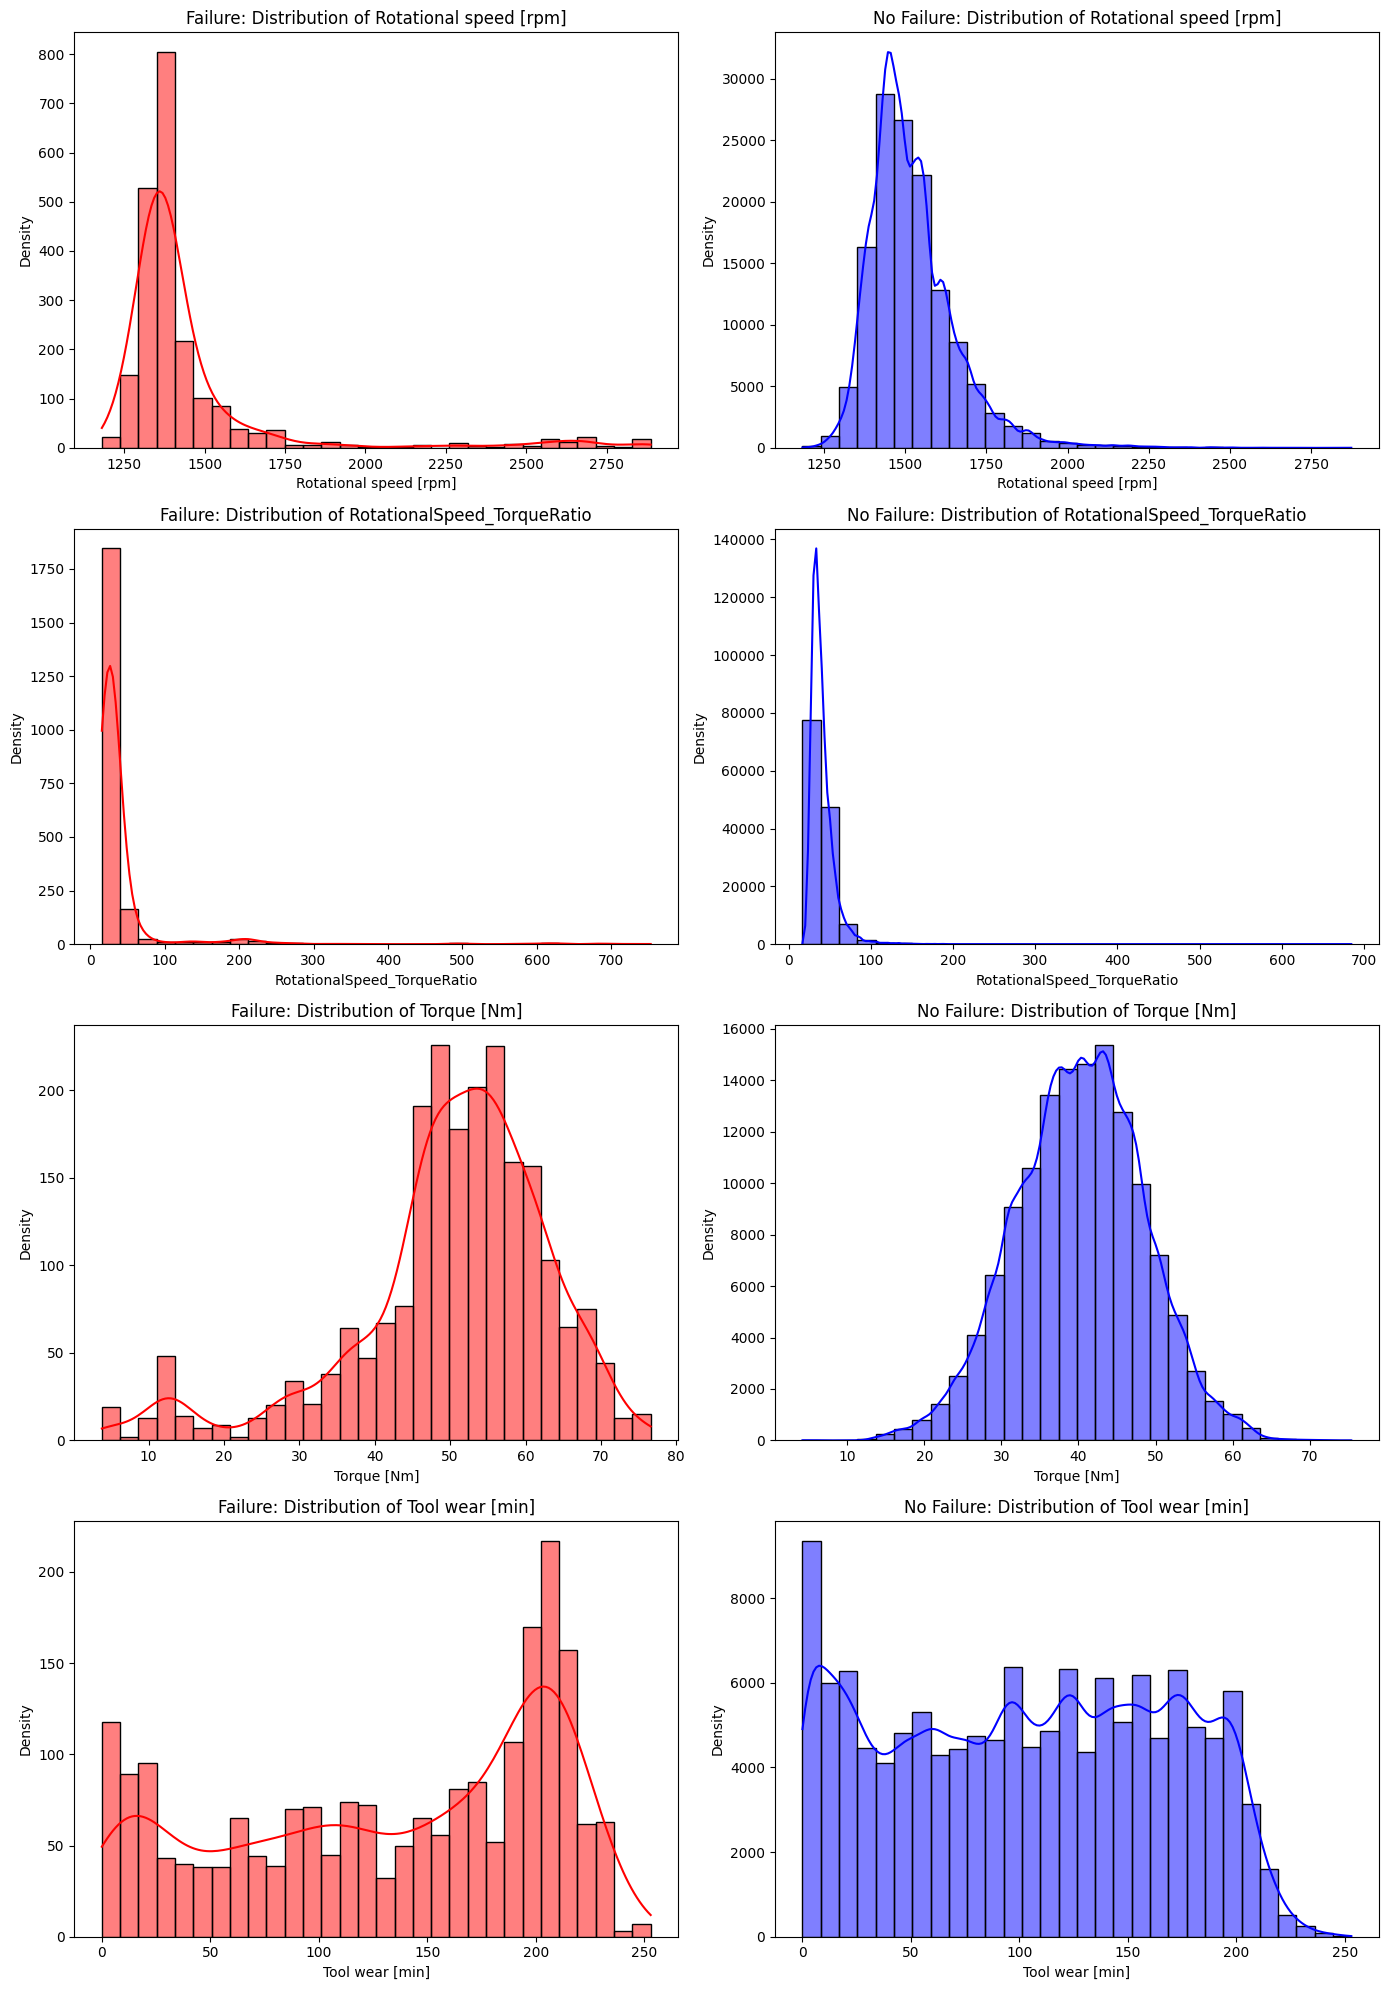

In [23]:
# 특성 중요도 계산
feature_importances = rf.feature_importances_
features = X.columns
importances_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importances_sorted = importances_df.sort_values(by='Importance', ascending=False)

# 상위 4개 변수 선택
top_4_features = importances_sorted['Feature'].head(4)

# 데이터 분리
failure_data = data_cleaned[data_cleaned['Machine failure'] == 1][top_4_features]
no_failure_data = data_cleaned[data_cleaned['Machine failure'] == 0][top_4_features]

# 변수 별 고장/비고장 분포 시각화
fig, axes = plt.subplots(4, 2, figsize=(14, 20))  # 각 상태 별로 4개의 변수를 개별적으로 시각화

for i, feature in enumerate(top_4_features):
    sns.histplot(failure_data[feature], bins=30, kde=True, color='red', ax=axes[i, 0])
    axes[i, 0].set_title(f'Failure: Distribution of {feature}')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Density')

    sns.histplot(no_failure_data[feature], bins=30, kde=True, color='blue', ax=axes[i, 1])
    axes[i, 1].set_title(f'No Failure: Distribution of {feature}')
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [ ]:

failure_data = renew_train[renew_train['Machine failure'] == 1]
non_failure_data = renew_train[renew_train['Machine failure'] == 0]


# 고장 상태와 비고장 상태에서의 RotationalSpeed_TorqueRatio와 Power 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 고장 상태에서의 RotationalSpeed_TorqueRatio 분포
sns.histplot(failure_data['RotationalSpeed_TorqueRatio'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('RotationalSpeed_TorqueRatio Distribution in Failure')

# 비고장 상태에서의 RotationalSpeed_TorqueRatio 분포
sns.histplot(non_failure_data['RotationalSpeed_TorqueRatio'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('RotationalSpeed_TorqueRatio Distribution in Non-Failure')

# 고장 상태에서의 Power 분포
sns.histplot(failure_data['Power'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Power Distribution in Failure')

# 비고장 상태에서의 Power 분포
sns.histplot(non_failure_data['Power'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Power Distribution in Non-Failure')

plt.tight_layout()
plt.show()

# 고장 및 비고장 상태에서의 RotationalSpeed_TorqueRatio와 Power에 대한 기술적 통계
failure_ratio_power_stats = failure_data[['RotationalSpeed_TorqueRatio', 'Power']].describe()
non_failure_ratio_power_stats = non_failure_data[['RotationalSpeed_TorqueRatio', 'Power']].describe()

failure_ratio_power_stats, non_failure_ratio_power_stats
